In [1]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler,PowerTransformer,OneHotEncoder,OrdinalEncoder

import optuna
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,f1_score,recall_score,precision_score,classification_report,roc_auc_score,confusion_matrix
from tensorflow.keras.metrics import Recall,Precision
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization,Input
from tensorflow.keras.regularizers import L1,L2,L1L2
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.activations import relu,tanh,softmax,leaky_relu,elu
from tensorflow.keras.initializers import HeNormal,GlorotNormal
from tensorflow.keras.optimizers import Adam,Adagrad,RMSprop,SGD
from tensorflow.keras.callbacks import EarlyStopping

In [2]:
df = pd.read_csv(r"C:\Users\boddu\Downloads\hotel_bookings.csv\hotel_bookings.csv")
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07


In [3]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'arrival_date_day_of_month', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies', 'meal',
       'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'assigned_room_type', 'booking_changes', 'deposit_type', 'agent',
       'company', 'days_in_waiting_list', 'customer_type', 'adr',
       'required_car_parking_spaces', 'total_of_special_requests',
       'reservation_status', 'reservation_status_date'],
      dtype='object')

In [4]:
df['reservation_status'].unique()

array(['Check-Out', 'Canceled', 'No-Show'], dtype=object)

In [5]:
df['country'].unique()

array(['PRT', 'GBR', 'USA', 'ESP', 'IRL', 'FRA', nan, 'ROU', 'NOR', 'OMN',
       'ARG', 'POL', 'DEU', 'BEL', 'CHE', 'CN', 'GRC', 'ITA', 'NLD',
       'DNK', 'RUS', 'SWE', 'AUS', 'EST', 'CZE', 'BRA', 'FIN', 'MOZ',
       'BWA', 'LUX', 'SVN', 'ALB', 'IND', 'CHN', 'MEX', 'MAR', 'UKR',
       'SMR', 'LVA', 'PRI', 'SRB', 'CHL', 'AUT', 'BLR', 'LTU', 'TUR',
       'ZAF', 'AGO', 'ISR', 'CYM', 'ZMB', 'CPV', 'ZWE', 'DZA', 'KOR',
       'CRI', 'HUN', 'ARE', 'TUN', 'JAM', 'HRV', 'HKG', 'IRN', 'GEO',
       'AND', 'GIB', 'URY', 'JEY', 'CAF', 'CYP', 'COL', 'GGY', 'KWT',
       'NGA', 'MDV', 'VEN', 'SVK', 'FJI', 'KAZ', 'PAK', 'IDN', 'LBN',
       'PHL', 'SEN', 'SYC', 'AZE', 'BHR', 'NZL', 'THA', 'DOM', 'MKD',
       'MYS', 'ARM', 'JPN', 'LKA', 'CUB', 'CMR', 'BIH', 'MUS', 'COM',
       'SUR', 'UGA', 'BGR', 'CIV', 'JOR', 'SYR', 'SGP', 'BDI', 'SAU',
       'VNM', 'PLW', 'QAT', 'EGY', 'PER', 'MLT', 'MWI', 'ECU', 'MDG',
       'ISL', 'UZB', 'NPL', 'BHS', 'MAC', 'TGO', 'TWN', 'DJI', 'STP',
       'KNA', 'E

In [6]:
df.dtypes

hotel                              object
is_canceled                         int64
lead_time                           int64
arrival_date_year                   int64
arrival_date_month                 object
arrival_date_week_number            int64
arrival_date_day_of_month           int64
stays_in_weekend_nights             int64
stays_in_week_nights                int64
adults                              int64
children                          float64
babies                              int64
meal                               object
country                            object
market_segment                     object
distribution_channel               object
is_repeated_guest                   int64
previous_cancellations              int64
previous_bookings_not_canceled      int64
reserved_room_type                 object
assigned_room_type                 object
booking_changes                     int64
deposit_type                       object
agent                             

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [8]:
df.drop(["reservation_status","reservation_status_date","company","agent","arrival_date_day_of_month","assigned_room_type"],axis=1,inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   stays_in_weekend_nights         119390 non-null  int64  
 7   stays_in_week_nights            119390 non-null  int64  
 8   adults                          119390 non-null  int64  
 9   children                        119386 non-null  float64
 10  babies                          119390 non-null  int64  
 11  meal                            119390 non-null  object 
 12  country         

In [10]:
df['children'] = df['children'].fillna(0) 

In [11]:
top_countries = df['country'].value_counts().head(10).index
df['country'] = df['country'].apply(lambda x: x if x in top_countries else 'Other')
df['country'] = df['country'].fillna('Unknown')

In [12]:
df.isna().sum()

hotel                             0
is_canceled                       0
lead_time                         0
arrival_date_year                 0
arrival_date_month                0
arrival_date_week_number          0
stays_in_weekend_nights           0
stays_in_week_nights              0
adults                            0
children                          0
babies                            0
meal                              0
country                           0
market_segment                    0
distribution_channel              0
is_repeated_guest                 0
previous_cancellations            0
previous_bookings_not_canceled    0
reserved_room_type                0
booking_changes                   0
deposit_type                      0
days_in_waiting_list              0
customer_type                     0
adr                               0
required_car_parking_spaces       0
total_of_special_requests         0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(33626)

In [14]:
df.drop_duplicates(ignore_index=True,inplace=True)

In [15]:
df

,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,...,previous_cancellations,previous_bookings_not_canceled,reserved_room_type,booking_changes,deposit_type,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests
0,Resort Hotel,0,342,2015,July,27,0,0,2,0.0,...,0,0,C,3,No Deposit,0,Transient,0.00,0,0
1,Resort Hotel,0,737,2015,July,27,0,0,2,0.0,...,0,0,C,4,No Deposit,0,Transient,0.00,0,0
2,Resort Hotel,0,7,2015,July,27,0,1,1,0.0,...,0,0,A,0,No Deposit,0,Transient,75.00,0,0
3,Resort Hotel,0,13,2015,July,27,0,1,1,0.0,...,0,0,A,0,No Deposit,0,Transient,75.00,0,0
4,Resort Hotel,0,14,2015,July,27,0,2,2,0.0,...,0,0,A,0,No Deposit,0,Transient,98.00,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85759,City Hotel,0,23,2017,August,35,2,5,2,0.0,...,0,0,A,0,No Deposit,0,Transient,96.14,0,0
85760,City Hotel,0,102,2017,August,35,2,5,3,0.0,...,0,0,E,0,No Deposit,0,Transient,225.43,0,2
85761,City Hotel,0,34,2017,August,35,2,5,2,0.0,...,0,0,D,0,No Deposit,0,Transient,157.71,0,4
85762,City Hotel,0,109,2017,August,35,2,5,2,0.0,...,0,0,A,0,No Deposit,0,Transient,104.40,0,0


In [16]:
df['arrival_date_year'].unique()

array([2015, 2016, 2017])

In [17]:
df["is_repeated_guest"].unique()

array([0, 1])

In [18]:
df["customer_type"].unique()

array(['Transient', 'Contract', 'Transient-Party', 'Group'], dtype=object)

In [19]:
df.duplicated().sum()

np.int64(0)

In [20]:
df.describe(include='object')

,hotel,arrival_date_month,meal,country,market_segment,distribution_channel,reserved_room_type,deposit_type,customer_type
count,85764,85764,85764,85764,85764,85764,85764,85764,85764
unique,2,12,5,11,8,5,10,3,4
top,City Hotel,August,BB,PRT,Online TA,TA/TO,A,No Deposit,Transient
freq,52282,11141,66762,26821,51304,67910,55084,84657,71471


In [21]:
df.describe(include='number')

,is_canceled,lead_time,arrival_date_year,arrival_date_week_number,stays_in_weekend_nights,stays_in_week_nights,adults,children,babies,is_repeated_guest,previous_cancellations,previous_bookings_not_canceled,booking_changes,days_in_waiting_list,adr,required_car_parking_spaces,total_of_special_requests
count,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000,85764.000000
mean,0.276561,79.222669,2016.215965,26.801000,1.011707,2.636339,1.880521,0.140852,0.011007,0.039667,0.030701,0.187351,0.272002,0.640572,106.705978,0.085607,0.706905
std,0.447300,85.391291,0.683805,13.663596,1.034035,2.060721,0.627286,0.459202,0.114563,0.195177,0.372250,1.748062,0.730109,9.282352,55.245101,0.283634,0.834143
min,0.000000,0.000000,2015.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-6.380000,0.000000,0.000000
25%,0.000000,11.000000,2016.000000,16.000000,0.000000,1.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,72.250000,0.000000,0.000000
50%,0.000000,49.000000,2016.000000,27.000000,1.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,98.935000,0.000000,1.000000
75%,1.000000,124.000000,2017.000000,37.000000,2.000000,4.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,135.000000,0.000000,1.000000
max,1.000000,737.000000,2017.000000,53.000000,19.000000,50.000000,55.000000,10.000000,10.000000,1.000000,26.000000,72.000000,21.000000,391.000000,5400.000000,8.000000,5.000000


In [22]:
df.describe(include="object").columns

Index(['hotel', 'arrival_date_month', 'meal', 'country', 'market_segment',
       'distribution_channel', 'reserved_room_type', 'deposit_type',
       'customer_type'],
      dtype='object')

In [23]:
df.describe(include="number").columns

Index(['is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_week_number', 'stays_in_weekend_nights',
       'stays_in_week_nights', 'adults', 'children', 'babies',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'booking_changes',
       'days_in_waiting_list', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [24]:
nominal_cols = ['hotel','meal','market_segment','distribution_channel','reserved_room_type',
           'deposit_type','customer_type','country']
ordinal_cols = ['arrival_date_month']
numerical_cols = ['lead_time','arrival_date_year','arrival_date_week_number','stays_in_weekend_nights',
             'stays_in_week_nights','adults','children','babies','previous_cancellations',
             'previous_bookings_not_canceled','booking_changes','days_in_waiting_list','adr',
             'required_car_parking_spaces','total_of_special_requests']

In [25]:
nominal_transformer = Pipeline([('Nominal',OneHotEncoder(sparse_output=False,handle_unknown='ignore'))])
nominal_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Nominal', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Speci

In [26]:
df['arrival_date_month'].unique()

array(['July', 'August', 'September', 'October', 'November', 'December',
       'January', 'February', 'March', 'April', 'May', 'June'],
      dtype=object)

In [27]:
month_order = [['January', 'February', 'March', 'April', 'May', 'June','July', 'August', 'September', 'October', 'November', 'December']]

In [28]:
ordinal_transformer = Pipeline([('Ordinal',OrdinalEncoder(categories=month_order))])
ordinal_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Ordinal', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute.","[['January', 'February', ...]]"
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'use_encoded_value'}, default='error'When set to 'error' an error will be raised in case an unknowncategorical feature is present during transform. When set to'use_encoded_value', the encoded value of unknown categories will beset to the value given for the parameter `unknown_value`. In:meth:`inverse_transform`, an unknown category will be denoted as None... versionadded:: 0.24",'error'
,"unknown_value unknown_value: int or np.nan, default=NoneWhen the parameter handle_unknown is set to 'use_encoded_value', thisparameter is required and will set the encoded value of unknowncategories. It has to be distinct from the values used to encode any ofthe categories in `fit`. If set to np.nan, the `dtype` parameter mustbe a float dtype... versionadded:: 0.24",None
,"encoded_missing_value encoded_missing_value: int or np.nan, default=np.nanEncoded value of missing categories. If set to `np.nan`, then the `dtype`parameter must be a float dtype... versionadded:: 1.1",nan
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.3 Read more in the :ref:`User Guide `.",None
,"max_categories max_categories: int, default=NoneSpecifies an upper limit to the number of output categories for each inputfeature when considering infrequent categories. If there are infrequentcategories, `ma

In [29]:
numerical_transformer = Pipeline([('Standard Numerical', StandardScaler())])
numerical_transformer

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Standard Numerical', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [30]:
preprocessor = ColumnTransformer([('nominal',nominal_transformer,nominal_cols),
                                  ('ordinal',ordinal_transformer,ordinal_cols),
                                 ('numerical',numerical_transformer,numerical_cols)],remainder='drop')
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('nominal', ...), ('ordinal', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_n

In [31]:
df.columns

Index(['hotel', 'is_canceled', 'lead_time', 'arrival_date_year',
       'arrival_date_month', 'arrival_date_week_number',
       'stays_in_weekend_nights', 'stays_in_week_nights', 'adults', 'children',
       'babies', 'meal', 'country', 'market_segment', 'distribution_channel',
       'is_repeated_guest', 'previous_cancellations',
       'previous_bookings_not_canceled', 'reserved_room_type',
       'booking_changes', 'deposit_type', 'days_in_waiting_list',
       'customer_type', 'adr', 'required_car_parking_spaces',
       'total_of_special_requests'],
      dtype='object')

In [32]:
X = df.drop(columns='is_canceled',axis=1)
Y = df['is_canceled']

In [33]:
X_train,X_temp,y_train,y_temp = train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

In [34]:
X_val,X_test,y_val,y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

In [35]:
X_train = preprocessor.fit_transform(X_train)
X_val = preprocessor.transform(X_val)
X_test = preprocessor.transform(X_test)

In [36]:
preprocessor.get_feature_names_out()

array(['nominal__hotel_City Hotel', 'nominal__hotel_Resort Hotel',
       'nominal__meal_BB', 'nominal__meal_FB', 'nominal__meal_HB',
       'nominal__meal_SC', 'nominal__meal_Undefined',
       'nominal__market_segment_Aviation',
       'nominal__market_segment_Complementary',
       'nominal__market_segment_Corporate',
       'nominal__market_segment_Direct', 'nominal__market_segment_Groups',
       'nominal__market_segment_Offline TA/TO',
       'nominal__market_segment_Online TA',
       'nominal__market_segment_Undefined',
       'nominal__distribution_channel_Corporate',
       'nominal__distribution_channel_Direct',
       'nominal__distribution_channel_GDS',
       'nominal__distribution_channel_TA/TO',
       'nominal__distribution_channel_Undefined',
       'nominal__reserved_room_type_A', 'nominal__reserved_room_type_B',
       'nominal__reserved_room_type_C', 'nominal__reserved_room_type_D',
       'nominal__reserved_room_type_E', 'nominal__reserved_room_type_F',
       'no

In [37]:
print("X_train shape:",X_train.shape)
print("X_val shape:",X_val.shape)
print("X_test shape:",X_test.shape)
print("-"*24)
print("Y_train shape:",y_train.shape)
print("Y_val shape:",y_val.shape)
print("Y_test shape:",y_test.shape)

X_train shape: (68611, 64)
X_val shape: (8576, 64)
X_test shape: (8577, 64)
------------------------
Y_train shape: (68611,)
Y_val shape: (8576,)
Y_test shape: (8577,)


In [38]:
df["is_canceled"].value_counts() # There is a class imbalance issue

is_canceled
0    62045
1    23719
Name: count, dtype: int64

<Axes: xlabel='is_canceled', ylabel='count'>

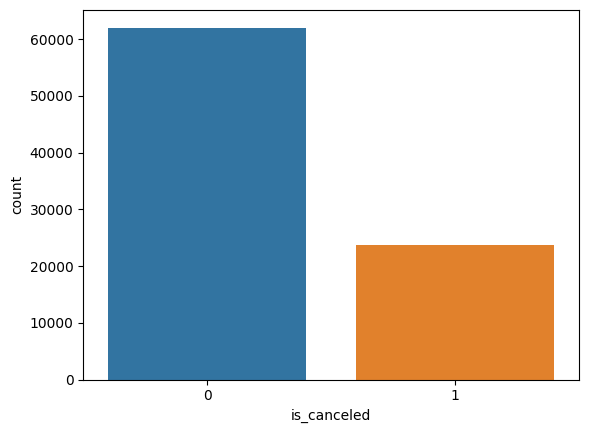

In [39]:
sns.countplot(x=df["is_canceled"],palette='tab10')

### Building ANN Architecture

In [40]:
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))
model.add(Dense(units=64,activation='relu'))
model.add(Dense(units=32,activation='relu'))
model.add(Dense(units=1,activation='sigmoid'))

In [41]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │           4,160 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 6,273 (24.50 KB)

 Trainable params: 6,273 (24.50 KB)

 Non-trainable params: 0 (0.00 B)

In [42]:
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy'])

In [43]:
X_train.shape,X_test.shape,X_val.shape

((68611, 64), (8577, 64), (8576, 64))

In [44]:
model.fit(X_train,y_train,epochs=20,batch_size=64,validation_data=(X_val,y_val))

Epoch 1/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7876 - loss: 0.4392 - val_accuracy: 0.8066 - val_loss: 0.3986
Epoch 2/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8147 - loss: 0.3888 - val_accuracy: 0.8052 - val_loss: 0.3999
Epoch 3/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8212 - loss: 0.3763 - val_accuracy: 0.8175 - val_loss: 0.3773
Epoch 4/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8259 - loss: 0.3676 - val_accuracy: 0.8198 - val_loss: 0.3726
Epoch 5/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8289 - loss: 0.3625 - val_accuracy: 0.8203 - val_loss: 0.3715
Epoch 6/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8310 - loss: 0.3580 - val_accuracy: 0.8238 - val_loss: 0.3664
Epoch 7/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8323 - loss: 0.3548 - val_accuracy: 0.8239 - val_loss: 0.3691
Epoch 8/20
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8336 - loss: 0.3516 - 

In [45]:
#ypred = np.argmax(model.predict(X_test),axis=1)
#accuracy_score(Y_test,ypred)

In [46]:
model.history.history['val_accuracy']

[0.8065531849861145,
 0.8051539063453674,
 0.8175140023231506,
 0.8198460936546326,
 0.8203125,
 0.8238106369972229,
 0.8239272236824036,
 0.8288246393203735,
 0.8263759613037109,
 0.8287079930305481,
 0.8302238583564758,
 0.8285914063453674,
 0.8295242786407471,
 0.8278917670249939,
 0.8290578126907349,
 0.8287079930305481,
 0.8302238583564758,
 0.8263759613037109,
 0.8311567306518555,
 0.8283582329750061]

In [47]:
model.history.history['val_loss']

[0.39861950278282166,
 0.39990687370300293,
 0.37730395793914795,
 0.37264323234558105,
 0.37148138880729675,
 0.3664284646511078,
 0.3690797686576843,
 0.36074188351631165,
 0.36372870206832886,
 0.3603998124599457,
 0.3606390655040741,
 0.360209196805954,
 0.35868579149246216,
 0.3667382299900055,
 0.3584425747394562,
 0.35932332277297974,
 0.3584049344062805,
 0.3625974655151367,
 0.362723171710968,
 0.3615110516548157]

In [48]:
model.predict(X_test)

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 963us/step


array([[3.2874674e-01],
       [2.9475091e-03],
       [2.3461427e-03],
       ...,
       [4.4948573e-04],
       [5.4390109e-01],
       [6.5062988e-01]], shape=(8577, 1), dtype=float32)

In [49]:
y_prob = model.predict(X_test)
ypred = np.where(y_prob > 0.5, 1, 0)
ypred

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 919us/step


array([[0],
       [0],
       [0],
       ...,
       [0],
       [1],
       [1]], shape=(8577, 1))

In [50]:
accuracy_score(y_test,ypred)

0.8290777661186896

In [51]:
print(classification_report(y_test,ypred))

              precision    recall  f1-score   support

           0       0.88      0.89      0.88      6205
           1       0.70      0.67      0.68      2372

    accuracy                           0.83      8577
   macro avg       0.79      0.78      0.78      8577
weighted avg       0.83      0.83      0.83      8577



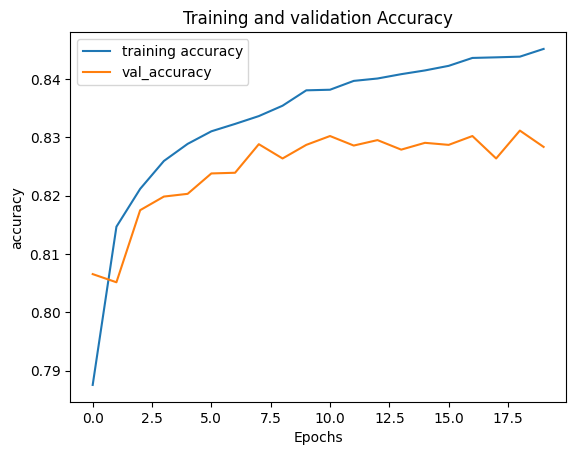

In [52]:
sns.lineplot(x=model.history.epoch,y=model.history.history['accuracy'],label='training accuracy')

sns.lineplot(x=model.history.epoch,y=model.history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.title('Training and validation Accuracy')
plt.show()

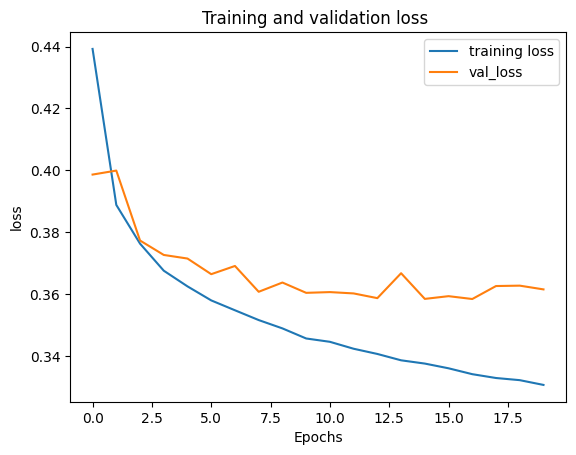

In [53]:
sns.lineplot(x=model.history.epoch,y=model.history.history['loss'],label='training loss')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_loss'],label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Training and validation loss ')
plt.show()

### Handling Class Imbalance

In [54]:
classes = np.unique(y_train)
weights = compute_class_weight(classes=classes,class_weight='balanced',y=y_train)
class_weights = dict(zip(classes,weights))
class_weights

{np.int64(0): np.float64(0.6911415101942139),
 np.int64(1): np.float64(1.807931488801054)}

In [55]:
df["is_canceled"].value_counts()

is_canceled
0    62045
1    23719
Name: count, dtype: int64

In [56]:
l1 = L1(l1=0.0003)
model = Sequential()
model.add(Input(shape=(X_train.shape[1],)))

model.add(Dense(128,activation='relu',kernel_regularizer=l1,kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(64,activation='relu',kernel_regularizer=l1,kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(32,activation='relu',kernel_regularizer=l1,kernel_initializer=HeNormal()))
model.add(BatchNormalization())
model.add(Dropout(0.2))

model.add(Dense(1,activation='sigmoid'))

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                      │ (None, 128)                 │           8,320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,585 (76.50 KB)

 Trainable params: 19,137 (74.75 KB)

 Non-trainable params: 448 (1.75 KB)

In [58]:
early_stopping = EarlyStopping(patience=5,monitor='val_loss',restore_best_weights=True)
model.compile(optimizer='adam',loss='binary_crossentropy',metrics=['accuracy',Precision(name='precision'),Recall(name='recall')])

In [59]:
model.fit(X_train,y_train,validation_data=(X_val,y_val),epochs=50,batch_size=64,callbacks=[early_stopping],class_weight=class_weights,verbose=1)

Epoch 1/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7010 - loss: 1.0877 - precision: 0.4743 - recall: 0.7482 - val_accuracy: 0.7306 - val_loss: 0.9191 - val_precision: 0.5077 - val_recall: 0.8655
Epoch 2/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7511 - loss: 0.7991 - precision: 0.5339 - recall: 0.7896 - val_accuracy: 0.7748 - val_loss: 0.6929 - val_precision: 0.5662 - val_recall: 0.7955
Epoch 3/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7590 - loss: 0.6530 - precision: 0.5438 - recall: 0.7994 - val_accuracy: 0.7669 - val_loss: 0.6134 - val_precision: 0.5524 - val_recall: 0.8284
Epoch 4/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7623 - loss: 0.5788 - precision: 0.5478 - recall: 0.8041 - val_accuracy: 0.7808 - val_loss: 0.5330 - val_precision: 0.5732 - val_recall: 0.8124
Epoch 5/50
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7660 - loss: 0.5414 - precision: 0.5527 - recall: 0.8077 - val_accuracy: 0.7531 - va

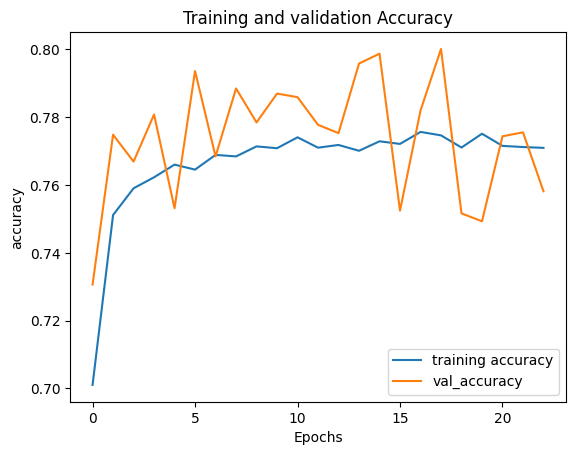

In [60]:
sns.lineplot(x=model.history.epoch,y=model.history.history['accuracy'],label='training accuracy')

sns.lineplot(x=model.history.epoch,y=model.history.history['val_accuracy'],label='val_accuracy')
plt.xlabel('Epochs')
plt.ylabel('accuracy')
plt.title('Training and validation Accuracy')
plt.show()

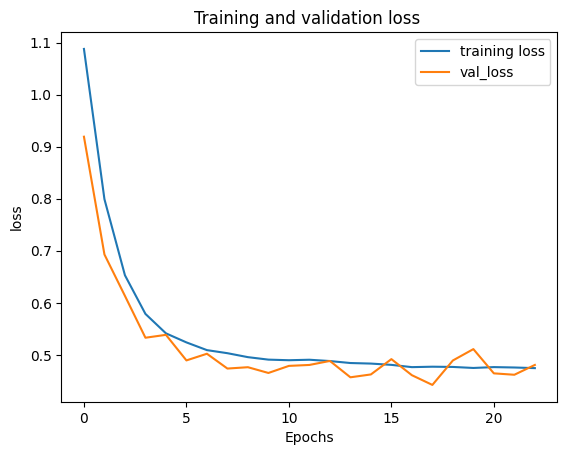

In [61]:
sns.lineplot(x=model.history.epoch,y=model.history.history['loss'],label='training loss')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_loss'],label='val_loss')
plt.xlabel('Epochs')
plt.ylabel('loss')
plt.title('Training and validation loss ')
plt.show()

<Axes: >

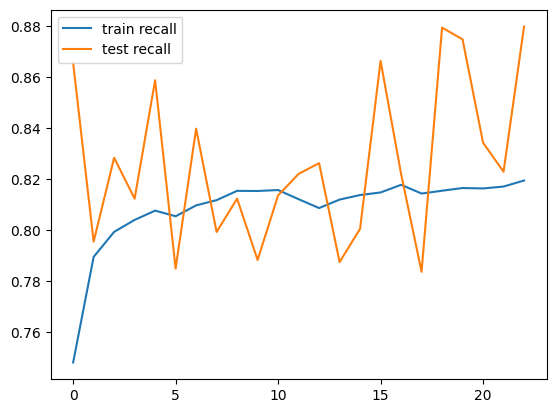

In [62]:
sns.lineplot(x=model.history.epoch,y=model.history.history['recall'],label='train recall')
sns.lineplot(x=model.history.epoch,y=model.history.history['val_recall'],label='test recall') 

In [71]:
y_prob = model.predict(X_test)
ypred = np.where(y_prob > 0.5,1,0)

print(classification_report(y_test, ypred))

269/269 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
              precision    recall  f1-score   support

           0       0.90      0.81      0.86      6205
           1       0.61      0.78      0.68      2372

    accuracy                           0.80      8577
   macro avg       0.76      0.79      0.77      8577
weighted avg       0.82      0.80      0.81      8577



In [74]:
accuracy_score(y_test,ypred)

0.8024950448874898

In [64]:
roc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc)

ROC-AUC Score: 0.8849767567633674


In [65]:
def objective(trial):

    n_layers = trial.suggest_int('n_layers', 1, 5)
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    dropout_rate = trial.suggest_float('dropout', 0.2, 0.5)
    activation = trial.suggest_categorical('activation', ['relu', 'tanh'])
    optimizer_name = trial.suggest_categorical('optimizer', ['adam', 'rmsprop'])

    l1 = trial.suggest_float('l1', 1e-5, 1e-2, log=True)
    l2 = trial.suggest_float('l2', 1e-5, 1e-2, log=True)

    model = Sequential()
    model.add(Input(shape=(X_train.shape[1],)))

    for i in range(n_layers):
        units = trial.suggest_int(f'units_{i}', 32, 128)

        model.add(Dense(
            units,
            activation=activation,
            kernel_initializer='he_normal',
            kernel_regularizer=L1L2(l1=l1, l2=l2)
        ))
        model.add(BatchNormalization())
        model.add(Dropout(dropout_rate))

    model.add(Dense(1, activation='sigmoid'))

    if optimizer_name == 'adam':
        optimizer = Adam(learning_rate=lr)
    else:
        optimizer = RMSprop(learning_rate=lr)

    model.compile(
        optimizer=optimizer,
        loss='binary_crossentropy',
        metrics=['accuracy', Precision(name='precision'), Recall(name='recall')]
    )

    early_stopping = EarlyStopping(
        monitor='val_loss',   
        patience=4,
        restore_best_weights=True
    )

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),   
        epochs=25,
        batch_size=64,
        callbacks=[early_stopping],
        verbose=1
    )

    precision = max(history.history['val_precision'])
    recall = max(history.history['val_recall'])

    f1 = 2 * (precision * recall) / (precision + recall + 1e-7)

    return f1

In [66]:
import optuna

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=15)

[I 2026-05-02 21:03:12,379] A new study created in memory with name: no-name-61444bf0-8602-466d-9aec-cc1617a4d69c


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.6416 - loss: 0.8637 - precision: 0.2947 - recall: 0.2124 - val_accuracy: 0.7234 - val_loss: 0.7048 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7142 - loss: 0.7157 - precision: 0.4442 - recall: 0.1330 - val_accuracy: 0.7561 - val_loss: 0.6384 - val_precision: 0.6842 - val_recall: 0.2192
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7436 - loss: 0.6430 - precision: 0.5761 - recall: 0.2764 - val_accuracy: 0.7796 - val_loss: 0.5799 - val_precision: 0.6553 - val_recall: 0.4288
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7599 - loss: 0.5982 - precision: 0.6135 - recall: 0.3560 - val_accuracy: 0.7858 - val_loss: 0.5508 - val_precision: 0.6660 - val_recall: 0.4524
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7723 - loss: 0.5670 - precision: 0.6415 - recall: 0.4002 - val_accuracy: 0.7

[I 2026-05-02 21:04:37,317] Trial 0 finished with value: 0.655369975577369 and parameters: {'n_layers': 4, 'lr': 0.00034905700520791554, 'dropout': 0.48539594547322207, 'activation': 'relu', 'optimizer': 'rmsprop', 'l1': 7.047970562905066e-05, 'l2': 8.635517918490732e-05, 'units_0': 65, 'units_1': 40, 'units_2': 43, 'units_3': 60}. Best is trial 0 with value: 0.655369975577369.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7639 - loss: 0.8749 - precision: 0.6009 - recall: 0.4352 - val_accuracy: 0.7893 - val_loss: 0.5157 - val_precision: 0.7016 - val_recall: 0.4144
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7844 - loss: 0.5148 - precision: 0.6648 - recall: 0.4444 - val_accuracy: 0.7806 - val_loss: 0.5030 - val_precision: 0.6157 - val_recall: 0.5497
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7835 - loss: 0.5096 - precision: 0.6635 - recall: 0.4406 - val_accuracy: 0.7940 - val_loss: 0.4922 - val_precision: 0.6527 - val_recall: 0.5451
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7845 - loss: 0.5069 - precision: 0.6666 - recall: 0.4418 - val_accuracy: 0.7792 - val_loss: 0.5126 - val_precision: 0.6086 - val_recall: 0.5645
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7839 - loss: 0.5048 - precision: 0.6637 - recall: 0.4432 - val_accuracy: 0.7843 - va

[I 2026-05-02 21:04:53,700] Trial 1 finished with value: 0.6634930536905169 and parameters: {'n_layers': 1, 'lr': 0.0016568533846421027, 'dropout': 0.411450089929137, 'activation': 'relu', 'optimizer': 'rmsprop', 'l1': 0.006670228983739556, 'l2': 0.0030724701632723382, 'units_0': 53}. Best is trial 1 with value: 0.6634930536905169.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.6795 - loss: 1.3845 - precision: 0.4277 - recall: 0.4705 - val_accuracy: 0.7726 - val_loss: 0.8722 - val_precision: 0.6715 - val_recall: 0.3482
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7632 - loss: 0.7487 - precision: 0.6034 - recall: 0.4194 - val_accuracy: 0.7822 - val_loss: 0.6135 - val_precision: 0.6941 - val_recall: 0.3798
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7784 - loss: 0.5927 - precision: 0.6437 - recall: 0.4450 - val_accuracy: 0.7847 - val_loss: 0.5343 - val_precision: 0.7152 - val_recall: 0.3685
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7869 - loss: 0.5251 - precision: 0.6623 - recall: 0.4680 - val_accuracy: 0.7898 - val_loss: 0.4879 - val_precision: 0.7204 - val_recall: 0.3921
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7943 - loss: 0.4865 - precision: 0.6808 - recall: 0.4825 - val_accuracy: 0.8029 - va

[I 2026-05-02 21:05:33,624] Trial 2 finished with value: 0.6557013271907407 and parameters: {'n_layers': 1, 'lr': 0.0002042910879838509, 'dropout': 0.3888074373222915, 'activation': 'relu', 'optimizer': 'rmsprop', 'l1': 0.0008093733063778172, 'l2': 0.008791036596127611, 'units_0': 51}. Best is trial 1 with value: 0.6634930536905169.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.7696 - loss: 0.5192 - precision: 0.6335 - recall: 0.3958 - val_accuracy: 0.7711 - val_loss: 0.4856 - val_precision: 0.6935 - val_recall: 0.3090
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7729 - loss: 0.4933 - precision: 0.6545 - recall: 0.3791 - val_accuracy: 0.7747 - val_loss: 0.4951 - val_precision: 0.5987 - val_recall: 0.5624
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7725 - loss: 0.4941 - precision: 0.6550 - recall: 0.3752 - val_accuracy: 0.7795 - val_loss: 0.4719 - val_precision: 0.6375 - val_recall: 0.4701
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7720 - loss: 0.4934 - precision: 0.6531 - recall: 0.3745 - val_accuracy: 0.7618 - val_loss: 0.5133 - val_precision: 0.7802 - val_recall: 0.1931
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7738 - loss: 0.4924 - precision: 0.6576 - recall: 0.3801 - val_accuracy: 0.7628 - va

[I 2026-05-02 21:05:50,622] Trial 3 finished with value: 0.6536437947217688 and parameters: {'n_layers': 1, 'lr': 0.008550540512953609, 'dropout': 0.4667643693942536, 'activation': 'tanh', 'optimizer': 'rmsprop', 'l1': 0.00017189503240583011, 'l2': 0.008052252696645234, 'units_0': 41}. Best is trial 1 with value: 0.6634930536905169.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7516 - loss: 1.4414 - precision: 0.5723 - recall: 0.4026 - val_accuracy: 0.7628 - val_loss: 0.5959 - val_precision: 0.7195 - val_recall: 0.2336
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7699 - loss: 0.5788 - precision: 0.6474 - recall: 0.3693 - val_accuracy: 0.6827 - val_loss: 0.6546 - val_precision: 0.4476 - val_recall: 0.6277
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7694 - loss: 0.5616 - precision: 0.6478 - recall: 0.3642 - val_accuracy: 0.7702 - val_loss: 0.5388 - val_precision: 0.7149 - val_recall: 0.2812
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7710 - loss: 0.5527 - precision: 0.6506 - recall: 0.3717 - val_accuracy: 0.7583 - val_loss: 0.5643 - val_precision: 0.7018 - val_recall: 0.2192
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7719 - loss: 0.5410 - precision: 0.6550 - recall: 0.3705 - val_accuracy: 0.7673 - va

[I 2026-05-02 21:06:36,252] Trial 4 finished with value: 0.7254425744773486 and parameters: {'n_layers': 2, 'lr': 0.0020893779986430527, 'dropout': 0.37473502126417635, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.004982208412890743, 'l2': 0.0012115970262952126, 'units_0': 75, 'units_1': 101}. Best is trial 4 with value: 0.7254425744773486.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.6884 - loss: 0.6734 - precision: 0.4317 - recall: 0.4008 - val_accuracy: 0.7715 - val_loss: 0.5439 - val_precision: 0.5893 - val_recall: 0.5734
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7516 - loss: 0.5745 - precision: 0.5659 - recall: 0.4376 - val_accuracy: 0.7760 - val_loss: 0.5248 - val_precision: 0.5875 - val_recall: 0.6383
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7682 - loss: 0.5470 - precision: 0.6022 - recall: 0.4764 - val_accuracy: 0.7830 - val_loss: 0.5149 - val_precision: 0.6038 - val_recall: 0.6265
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7773 - loss: 0.5312 - precision: 0.6217 - recall: 0.4971 - val_accuracy: 0.7825 - val_loss: 0.5158 - val_precision: 0.5961 - val_recall: 0.6627
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7836 - loss: 0.5205 - precision: 0.6366 - recall: 0.5072 - val_accuracy: 0.7928 - va

[I 2026-05-02 21:08:32,107] Trial 5 finished with value: 0.6891850121195958 and parameters: {'n_layers': 5, 'lr': 0.00029941153357444165, 'dropout': 0.21240999938622632, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 1.6591772395619026e-05, 'l2': 4.587680963578059e-05, 'units_0': 66, 'units_1': 34, 'units_2': 34, 'units_3': 111, 'units_4': 75}. Best is trial 4 with value: 0.7254425744773486.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7605 - loss: 0.9756 - precision: 0.6021 - recall: 0.3955 - val_accuracy: 0.7431 - val_loss: 0.7366 - val_precision: 0.9333 - val_recall: 0.0767
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7719 - loss: 0.6144 - precision: 0.6434 - recall: 0.3933 - val_accuracy: 0.7622 - val_loss: 0.6069 - val_precision: 0.7916 - val_recall: 0.1906
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7720 - loss: 0.5816 - precision: 0.6463 - recall: 0.3882 - val_accuracy: 0.7755 - val_loss: 0.5775 - val_precision: 0.6819 - val_recall: 0.3533
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7735 - loss: 0.5713 - precision: 0.6485 - recall: 0.3955 - val_accuracy: 0.7859 - val_loss: 0.5751 - val_precision: 0.6806 - val_recall: 0.4258
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7752 - loss: 0.5764 - precision: 0.6558 - recall: 0.3938 - val_accuracy: 0.7566 - va

[I 2026-05-02 21:09:10,790] Trial 6 finished with value: 0.7836751526597864 and parameters: {'n_layers': 3, 'lr': 0.008378773738051806, 'dropout': 0.20524729852061274, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.0031315382426723155, 'l2': 0.0010410837838339734, 'units_0': 76, 'units_1': 62, 'units_2': 98}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7749 - loss: 0.6512 - precision: 0.6355 - recall: 0.4365 - val_accuracy: 0.7716 - val_loss: 0.5427 - val_precision: 0.7282 - val_recall: 0.2778
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7840 - loss: 0.5117 - precision: 0.6615 - recall: 0.4487 - val_accuracy: 0.7807 - val_loss: 0.4860 - val_precision: 0.6417 - val_recall: 0.4688
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7857 - loss: 0.4974 - precision: 0.6643 - recall: 0.4548 - val_accuracy: 0.7906 - val_loss: 0.4787 - val_precision: 0.6593 - val_recall: 0.5025
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7849 - loss: 0.4889 - precision: 0.6648 - recall: 0.4480 - val_accuracy: 0.7759 - val_loss: 0.4775 - val_precision: 0.7440 - val_recall: 0.2892
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7846 - loss: 0.4807 - precision: 0.6636 - recall: 0.4484 - val_accuracy: 0.7936 - va

[I 2026-05-02 21:10:03,168] Trial 7 finished with value: 0.7035649989717273 and parameters: {'n_layers': 3, 'lr': 0.006435299780609927, 'dropout': 0.36565178172172597, 'activation': 'relu', 'optimizer': 'adam', 'l1': 4.535136042161796e-05, 'l2': 0.0015237447817147479, 'units_0': 60, 'units_1': 125, 'units_2': 81}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7475 - loss: 0.9807 - precision: 0.5657 - recall: 0.3754 - val_accuracy: 0.7933 - val_loss: 0.7516 - val_precision: 0.6934 - val_recall: 0.4528
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.7907 - loss: 0.6506 - precision: 0.6706 - recall: 0.4781 - val_accuracy: 0.8036 - val_loss: 0.5479 - val_precision: 0.6727 - val_recall: 0.5649
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7980 - loss: 0.5369 - precision: 0.6786 - recall: 0.5124 - val_accuracy: 0.8029 - val_loss: 0.5070 - val_precision: 0.7639 - val_recall: 0.4161
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7991 - loss: 0.5047 - precision: 0.6801 - recall: 0.5167 - val_accuracy: 0.8047 - val_loss: 0.4833 - val_precision: 0.7442 - val_recall: 0.4477
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7985 - loss: 0.4995 - precision: 0.6756 - recall: 0.5222 - val_accuracy: 0.8105 - va

[I 2026-05-02 21:11:46,896] Trial 8 finished with value: 0.7222780414768479 and parameters: {'n_layers': 5, 'lr': 0.0021213657750965603, 'dropout': 0.342007063124473, 'activation': 'relu', 'optimizer': 'adam', 'l1': 0.00016390523742168712, 'l2': 7.503132112662595e-05, 'units_0': 53, 'units_1': 82, 'units_2': 86, 'units_3': 68, 'units_4': 57}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7634 - loss: 0.8735 - precision: 0.6174 - recall: 0.3801 - val_accuracy: 0.7477 - val_loss: 0.6160 - val_precision: 0.8291 - val_recall: 0.1105
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7704 - loss: 0.6097 - precision: 0.6405 - recall: 0.3871 - val_accuracy: 0.7766 - val_loss: 0.5921 - val_precision: 0.7077 - val_recall: 0.3276
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7712 - loss: 0.5990 - precision: 0.6429 - recall: 0.3881 - val_accuracy: 0.7563 - val_loss: 0.6999 - val_precision: 0.7382 - val_recall: 0.1842
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7691 - loss: 0.5963 - precision: 0.6429 - recall: 0.3715 - val_accuracy: 0.7708 - val_loss: 0.5843 - val_precision: 0.7026 - val_recall: 0.2968
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7710 - loss: 0.5946 - precision: 0.6465 - recall: 0.3792 - val_accuracy: 0.7641 - va

[I 2026-05-02 21:12:26,725] Trial 9 finished with value: 0.6823839233496034 and parameters: {'n_layers': 3, 'lr': 0.005514382773922032, 'dropout': 0.2608644059614074, 'activation': 'relu', 'optimizer': 'rmsprop', 'l1': 0.003250031837838327, 'l2': 0.0051286281558721655, 'units_0': 89, 'units_1': 33, 'units_2': 36}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.7213 - loss: 2.7993 - precision: 0.4959 - recall: 0.4707 - val_accuracy: 0.7842 - val_loss: 1.7117 - val_precision: 0.6078 - val_recall: 0.6193
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7751 - loss: 1.1802 - precision: 0.6182 - recall: 0.4884 - val_accuracy: 0.7852 - val_loss: 0.7695 - val_precision: 0.6445 - val_recall: 0.4983
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7804 - loss: 0.6437 - precision: 0.6417 - recall: 0.4667 - val_accuracy: 0.7708 - val_loss: 0.5524 - val_precision: 0.6501 - val_recall: 0.3706
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7814 - loss: 0.5364 - precision: 0.6558 - recall: 0.4414 - val_accuracy: 0.7877 - val_loss: 0.5011 - val_precision: 0.6351 - val_recall: 0.5460
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.7825 - loss: 0.5095 - precision: 0.6620 - recall: 0.4366 - val_accuracy: 0.7880 - va

[I 2026-05-02 21:13:59,583] Trial 10 finished with value: 0.6855767356908021 and parameters: {'n_layers': 4, 'lr': 0.0006572890657101165, 'dropout': 0.29238407034467506, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.000951211610589689, 'l2': 0.000345874881534927, 'units_0': 115, 'units_1': 62, 'units_2': 117, 'units_3': 35}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7545 - loss: 1.5109 - precision: 0.5876 - recall: 0.3763 - val_accuracy: 0.6460 - val_loss: 0.7768 - val_precision: 0.4189 - val_recall: 0.7226
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7666 - loss: 0.6134 - precision: 0.6426 - recall: 0.3513 - val_accuracy: 0.7731 - val_loss: 0.5813 - val_precision: 0.6247 - val_recall: 0.4498
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7662 - loss: 0.5959 - precision: 0.6416 - recall: 0.3506 - val_accuracy: 0.7615 - val_loss: 0.5794 - val_precision: 0.6982 - val_recall: 0.2428
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7668 - loss: 0.5856 - precision: 0.6474 - recall: 0.3440 - val_accuracy: 0.7744 - val_loss: 0.5698 - val_precision: 0.6187 - val_recall: 0.4802
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7661 - loss: 0.5781 - precision: 0.6456 - recall: 0.3422 - val_accuracy: 0.7631 - va

[I 2026-05-02 21:14:39,935] Trial 11 finished with value: 0.7521200184798981 and parameters: {'n_layers': 2, 'lr': 0.0028896090847619804, 'dropout': 0.307144966115634, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.009025797457774928, 'l2': 0.0005243035276453014, 'units_0': 90, 'units_1': 99}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7695 - loss: 0.8369 - precision: 0.6161 - recall: 0.4417 - val_accuracy: 0.7751 - val_loss: 0.5606 - val_precision: 0.6389 - val_recall: 0.4296
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7844 - loss: 0.5326 - precision: 0.6675 - recall: 0.4394 - val_accuracy: 0.7487 - val_loss: 0.5751 - val_precision: 0.9064 - val_recall: 0.1020
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7882 - loss: 0.5004 - precision: 0.6748 - recall: 0.4517 - val_accuracy: 0.7948 - val_loss: 0.4827 - val_precision: 0.6521 - val_recall: 0.5531
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7884 - loss: 0.4889 - precision: 0.6754 - recall: 0.4519 - val_accuracy: 0.7976 - val_loss: 0.4613 - val_precision: 0.6476 - val_recall: 0.5881
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7875 - loss: 0.4857 - precision: 0.6726 - recall: 0.4516 - val_accuracy: 0.7907 - va

[I 2026-05-02 21:15:06,427] Trial 12 finished with value: 0.7133521355964508 and parameters: {'n_layers': 2, 'lr': 0.0036711693010103076, 'dropout': 0.2368844280671425, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.0016977378017357858, 'l2': 0.00036385217199292377, 'units_0': 95, 'units_1': 81}. Best is trial 6 with value: 0.7836751526597864.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7547 - loss: 1.2315 - precision: 0.6000 - recall: 0.3389 - val_accuracy: 0.7706 - val_loss: 0.7604 - val_precision: 0.6174 - val_recall: 0.4490
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7602 - loss: 0.7644 - precision: 0.6272 - recall: 0.3276 - val_accuracy: 0.7456 - val_loss: 0.7262 - val_precision: 0.6610 - val_recall: 0.1644
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7609 - loss: 0.7415 - precision: 0.6321 - recall: 0.3238 - val_accuracy: 0.6642 - val_loss: 0.8737 - val_precision: 0.4424 - val_recall: 0.8225
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7586 - loss: 0.7419 - precision: 0.6243 - recall: 0.3194 - val_accuracy: 0.7497 - val_loss: 0.7740 - val_precision: 0.7737 - val_recall: 0.1341
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7598 - loss: 0.7377 - precision: 0.6259 - recall: 0.3268 - val_accuracy: 0.6999 - va

[I 2026-05-02 21:15:27,802] Trial 13 finished with value: 0.797371938843134 and parameters: {'n_layers': 2, 'lr': 0.009903560503169838, 'dropout': 0.3084937099280112, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.008914227147824434, 'l2': 0.0007904110716854928, 'units_0': 108, 'units_1': 103}. Best is trial 13 with value: 0.797371938843134.


Epoch 1/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7640 - loss: 0.9814 - precision: 0.6074 - recall: 0.4147 - val_accuracy: 0.7010 - val_loss: 0.7238 - val_precision: 0.4519 - val_recall: 0.3803
Epoch 2/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7764 - loss: 0.6081 - precision: 0.6529 - recall: 0.4092 - val_accuracy: 0.7449 - val_loss: 0.6089 - val_precision: 0.8770 - val_recall: 0.0902
Epoch 3/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7762 - loss: 0.5854 - precision: 0.6545 - recall: 0.4040 - val_accuracy: 0.7559 - val_loss: 0.5968 - val_precision: 0.5461 - val_recall: 0.6960
Epoch 4/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7785 - loss: 0.5734 - precision: 0.6582 - recall: 0.4146 - val_accuracy: 0.7809 - val_loss: 0.5424 - val_precision: 0.7077 - val_recall: 0.3541
Epoch 5/25
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.7804 - loss: 0.5660 - precision: 0.6624 - recall: 0.4200 - val_accuracy: 0.7702 - va

[I 2026-05-02 21:16:00,421] Trial 14 finished with value: 0.7920978851742524 and parameters: {'n_layers': 3, 'lr': 0.009195007008459955, 'dropout': 0.20256161380421284, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.0021228403887772473, 'l2': 0.000999842152845024, 'units_0': 127, 'units_1': 63, 'units_2': 122}. Best is trial 13 with value: 0.797371938843134.


In [67]:
print("Best Params:", study.best_params)
print("Best Score:", study.best_value)

Best Params: {'n_layers': 2, 'lr': 0.009903560503169838, 'dropout': 0.3084937099280112, 'activation': 'tanh', 'optimizer': 'adam', 'l1': 0.008914227147824434, 'l2': 0.0007904110716854928, 'units_0': 108, 'units_1': 103}
Best Score: 0.797371938843134


In [75]:
accuracy_score(y_test,ypred) # without hyper parameters

0.8024950448874898

In [118]:
import joblib
with open(r"D:\Hotel Booking Cancellation Prediction\ann_model.pkl","wb") as file:
    joblib.dump(preprocessor,file)

In [84]:
model.save(r"D:\Hotel Booking Cancellation Prediction\model.keras")